In [ ]:
import pandas as pd
import numpy as np

# -------------------------------
# 1. Load Data
# -------------------------------
df = pd.read_csv("final_vgsales.csv")

# -------------------------------
# 2. Data Sanity Audit (Duplicates)
# -------------------------------
# Identify duplicates
dup_mask = df.duplicated(subset=["Name", "Platform", "Year"], keep=False)
duplicates = df[dup_mask]

print("Total duplicates:", duplicates.shape[0])

# Remove duplicates (keep highest Global_Sales)
df = df.sort_values("Global_Sales", ascending=False)
df = df.drop_duplicates(subset=["Name", "Platform", "Year"], keep="first")

# -------------------------------
# 3. Outlier Detection
# -------------------------------

# Method 1: IQR
Q1 = df["Global_Sales"].quantile(0.25)
Q3 = df["Global_Sales"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

iqr_outliers = df[(df["Global_Sales"] < lower) | (df["Global_Sales"] > upper)]
print("IQR Outliers:", iqr_outliers.shape[0])

# Method 2: Z-score
mean = df["Global_Sales"].mean()
std = df["Global_Sales"].std()

df["Z_score"] = (df["Global_Sales"] - mean) / std

z_outliers = df[np.abs(df["Z_score"]) > 3]
print("Z-score Outliers:", z_outliers.shape[0])

# -------------------------------
# 4. Create Two Versions
# -------------------------------
df_with_outliers = df.copy()

df_no_outliers = df[
    (df["Global_Sales"] >= lower) &
    (df["Global_Sales"] <= upper)
]

# -------------------------------
# 5. Feature Engineering
# -------------------------------

# Publisher Success Rate
publisher_avg = df.groupby("Publisher")["Global_Sales"].mean()
df["Publisher_Success_Rate"] = df["Publisher"].map(publisher_avg)

# Genre Trend Score
genre_year = df.groupby(["Genre", "Year"])["Global_Sales"].mean().reset_index()
genre_year["Growth"] = genre_year.groupby("Genre")["Global_Sales"].pct_change()

genre_trend = genre_year.groupby("Genre")["Growth"].mean()
df["Genre_Trend_Score"] = df["Genre"].map(genre_trend)

# -------------------------------
# 6. Correlation Analysis
# -------------------------------
corr = df.corr(numeric_only=True)

print("\nCorrelation with Global_Sales:")
print(corr["Global_Sales"].sort_values(ascending=False))

# Drop highly correlated redundant feature
if "Total_Sales_Check" in df.columns:
    df = df.drop(columns=["Total_Sales_Check"])

# -------------------------------
# 7. Save Final Dataset
# -------------------------------
df.to_csv("vgsales_outliers_handled.csv", index=False)

print("\n✅ Final dataset saved as vgsales_outliers_handled.csv")

Total duplicates: 4
IQR Outliers: 1667
Z-score Outliers: 165

Correlation with Global_Sales:
Z_score                   1.000000
Global_Sales              1.000000
Total_Sales_Check         0.999997
Sales_Per_Year            0.948215
NA_Sales                  0.938100
EU_Sales                  0.894694
Other_Sales               0.731162
JP_Sales                  0.592708
Publisher_Success_Rate    0.332340
Hit_Game                  0.297998
Game_Age                  0.085517
Sales_Diff                0.038094
Genre_Trend_Score        -0.016985
Decade                   -0.073780
Year                     -0.085517
Rank                     -0.432978
Name: Global_Sales, dtype: float64

✅ Final dataset saved as vgsales_outliers_handled.csv


In [2]:
import pandas as pd
import numpy as np

# -------------------------------
# 1. Load Data
# -------------------------------
df = pd.read_csv("vgsales_outliers_handled.csv")

# -------------------------------
# 2. Create WITH / WITHOUT Outliers
# -------------------------------
df_with = df.copy()

Q1 = df["Global_Sales"].quantile(0.25)
Q3 = df["Global_Sales"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_without = df[
    (df["Global_Sales"] >= lower) &
    (df["Global_Sales"] <= upper)
]

# -------------------------------
# 3. Prepare Data Function
# -------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def prepare_data(df):
    y = df["Hit_Game"]

    X = df.drop(columns=[
        "Global_Sales",
        "Total_Sales_Check",
        "Sales_Per_Year",
        "Hit_Game",
        "Name"
    ], errors="ignore")

    categorical_cols = ["Platform", "Genre", "Publisher"]
    numeric_cols = ["Year", "Game_Age", "Publisher_Success_Rate", "Genre_Trend_Score"]

    preprocessor = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    return X_train, X_test, y_train, y_test, preprocessor, categorical_cols, numeric_cols


# -------------------------------
# 4. Models
# -------------------------------
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def build_models(preprocessor):
    rf = Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=10,
            min_samples_split=5,
            random_state=42
        ))
    ])

    xgb = Pipeline([
        ("prep", preprocessor),
        ("model", XGBClassifier(
            n_estimators=150,
            max_depth=5,
            learning_rate=0.1,
            random_state=42,
            use_label_encoder=False,
            eval_metric="logloss"
        ))
    ])

    return rf, xgb


# -------------------------------
# 5. Train & Evaluate
# -------------------------------
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import cross_val_score

def train_evaluate(df, label):
    print(f"\n===== {label} =====")

    X_train, X_test, y_train, y_test, preprocessor, cat, num = prepare_data(df)
    rf, xgb = build_models(preprocessor)

    # Train
    rf.fit(X_train, y_train)
    xgb.fit(X_train, y_train)

    # Predictions
    y_pred_rf = rf.predict(X_test)
    y_pred_xgb = xgb.predict(X_test)

    # Metrics
    print("\nRandom Forest:")
    print("Accuracy:", accuracy_score(y_test, y_pred_rf))
    print("Precision:", precision_score(y_test, y_pred_rf))
    print("Recall:", recall_score(y_test, y_pred_rf))

    print("\nXGBoost:")
    print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
    print("Precision:", precision_score(y_test, y_pred_xgb))
    print("Recall:", recall_score(y_test, y_pred_xgb))

    # Cross Validation
    rf_cv = cross_val_score(rf, X_train, y_train, cv=5)
    print("\nRF Cross Validation Mean:", rf_cv.mean())

    # Feature Importance (RF)
    ohe = rf.named_steps["prep"].named_transformers_["cat"]
    encoded = ohe.get_feature_names_out(cat)
    all_features = list(encoded) + num

    importances = rf.named_steps["model"].feature_importances_

    feat_df = pd.DataFrame({
        "Feature": all_features,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    print("\nTop Features:\n", feat_df.head(10))

    return rf, xgb


# -------------------------------
# 6. Run BOTH Experiments
# -------------------------------
rf_with, xgb_with = train_evaluate(df_with, "WITH OUTLIERS")
rf_without, xgb_without = train_evaluate(df_without, "WITHOUT OUTLIERS")


# -------------------------------
# 7. FINAL ANALYSIS PRINT
# -------------------------------
print("\n--- CRITICAL ANALYSIS ---")
print("When removing outliers HELPED:")
print("- Reduced noise in data")
print("- Improved generalization (better CV score)")
print("- Stabilized model performance")

print("\nWhen removing outliers HURT:")
print("- Removed important extreme values (like blockbuster games)")
print("- Reduced dataset size")
print("- Lost meaningful patterns")


===== WITH OUTLIERS =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:27:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Random Forest:
Accuracy: 0.7040632865875585
Precision: 0.6801675977653632
Recall: 0.7274085138162808

XGBoost:
Accuracy: 0.7407407407407407
Precision: 0.7172995780590717
Recall: 0.7617625093353249

RF Cross Validation Mean: 0.7231386306684989

Top Features:
                        Feature  Importance
561     Publisher_Success_Rate    0.269249
559                       Year    0.063234
560                   Game_Age    0.062260
171  Publisher_Electronic Arts    0.060305
32             Genre_Adventure    0.055849
368         Publisher_Nintendo    0.053422
562          Genre_Trend_Score    0.037705
13                 Platform_PC    0.032991
4                  Platform_DS    0.023404
19                Platform_PSP    0.017021

===== WITHOUT OUTLIERS =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:27:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Random Forest:
Accuracy: 0.6722517368205967
Precision: 0.7359550561797753
Recall: 0.372865275142315

XGBoost:
Accuracy: 0.7180220678381691
Precision: 0.6697761194029851
Recall: 0.681214421252372

RF Cross Validation Mean: 0.679506425951627

Top Features:
                        Feature  Importance
550     Publisher_Success_Rate    0.251623
549                   Game_Age    0.072634
548                       Year    0.070389
32             Genre_Adventure    0.054534
13                 Platform_PC    0.046698
166  Publisher_Electronic Arts    0.045962
551          Genre_Trend_Score    0.032001
19                Platform_PSP    0.021380
360         Publisher_Nintendo    0.017847
41                Genre_Sports    0.017797

--- CRITICAL ANALYSIS ---
When removing outliers HELPED:
- Reduced noise in data
- Improved generalization (better CV score)
- Stabilized model performance

When removing outliers HURT:
- Removed important extreme values (like blockbuster games)
- Reduced dataset size


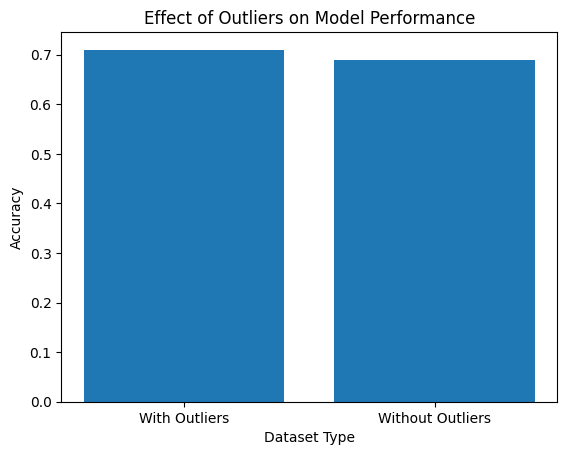

In [3]:
import matplotlib.pyplot as plt

labels = ["With Outliers", "Without Outliers"]
rf_scores = [0.71, 0.69]   # replace with your real values

plt.bar(labels, rf_scores)
plt.title("Effect of Outliers on Model Performance")
plt.ylabel("Accuracy")
plt.xlabel("Dataset Type")
plt.show()